In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')


RANDOM_STATE = 67
np.random.seed(RANDOM_STATE)
sns.set(style='whitegrid', font_scale=1.3, palette='Set2')

# Exploratory Data Analysis

In [11]:
data = pd.read_stata('Data for Group Assignment 1.dta')

In [12]:
data.head()

,id,year,TRBCEconomicSectorName,TRBCBusinessSectorName,TRBCIndustryGroupName,female,roa,trev,cogs,gp,...,teq,marcap,emp,beta,esgs,ind,dirnetwork,age,nquals,boardsize
0,12.0,2007.0,Energy,Uranium,Uranium,0.0,-35.743146,9.820262e+05,NaN,NaN,...,1.960230e+07,7.461715e+07,20.0,NaN,NaN,0.400000,444.600000,71.000000,2.800000,5.0
1,12.0,2008.0,Energy,Uranium,Uranium,0.0,-30.299690,2.072448e+06,NaN,NaN,...,1.520079e+07,1.834640e+07,29.0,NaN,NaN,0.333333,409.666667,59.000000,2.666667,6.0
2,12.0,2009.0,Energy,Uranium,Uranium,0.0,-36.862254,4.024032e+05,NaN,NaN,...,1.566843e+07,9.226658e+07,15.0,NaN,NaN,0.285714,372.428571,60.000000,2.714286,7.0
3,12.0,2010.0,Energy,Uranium,Uranium,0.0,-54.475718,4.893411e+05,NaN,NaN,...,1.509513e+07,1.878285e+08,37.0,NaN,19.809704,0.285714,402.428571,60.333332,2.428571,7.0
4,12.0,2011.0,Energy,Uranium,Uranium,0.0,-36.467285,9.539094e+05,NaN,NaN,...,4.743890e+07,4.956273e+07,44.0,NaN,14.846020,0.166667,93.333333,56.500000,1.666667,6.0


## Обработка данных

Выборка ограничивается фирмами с размером совета директоров, равным 4 или 5 в 2010 году. Это определяет группы treatment (5 человек) и control (4 человека) на основе экзогенного признака, измеренного до объявления политики.

In [69]:
boardsize_2010 = data[data['year'] == 2010][['id', 'boardsize']].copy()

firms_did = boardsize_2010[boardsize_2010['boardsize'].isin([4, 5])].copy()
firms_did['Treat'] = (firms_did['boardsize'] == 5).astype(int)

print("Распределение board size в 2010:")
print(firms_did['boardsize'].value_counts().sort_index())

Распределение board size в 2010:
boardsize
4.0     65
5.0    138
Name: count, dtype: int64


Период до вмешательства будет включать 2010 год и все предшествующие годы. Период после вмешательства будет включать 2015 год и последующие. Промежуточные годы (2011-2014) исключим из анализа, так как политика была объявлена, но ещё не вступила в силу.

In [70]:
data_did = data[data['id'].isin(firms_did['id'])].copy()
data_did = data_did[data_did['year'].isin([2006, 2007, 2008, 2009, 2010, 2015, 2016, 2017, 2018])].copy()
data_did = data_did.merge(firms_did[['id', 'Treat']], on='id', how='left')

Post - индикатор пост-периода (2015 и позже)

Treat_Post - произведение индикатора группы лечения и пост-периода

In [71]:
data_did['Post'] = (data_did['year'] >= 2015).astype(int)
data_did['Treat_Post'] = data_did['Treat'] * data_did['Post']

In [72]:
data_did.head()

,id,year,TRBCEconomicSectorName,TRBCBusinessSectorName,TRBCIndustryGroupName,female,roa,trev,cogs,gp,...,beta,esgs,ind,dirnetwork,age,nquals,boardsize,Treat,Post,Treat_Post
0,305.0,2006.0,Basic Materials,Mineral Resources,Metals & Mining,0.0,0.928317,5168890.80,2060799.60,3108091.20,...,NaN,NaN,0.5,1355.75,54.75,2.25,4.0,0,0,0
1,305.0,2007.0,Basic Materials,Mineral Resources,Metals & Mining,0.0,55.624764,32435783.62,6453509.96,25982273.66,...,NaN,NaN,0.5,1355.75,55.75,2.25,4.0,0,0,0
2,305.0,2008.0,Basic Materials,Mineral Resources,Metals & Mining,0.0,16.568179,26039560.05,5324575.60,20714984.45,...,NaN,NaN,0.5,1355.75,56.75,2.25,4.0,0,0,0
3,305.0,2009.0,Basic Materials,Mineral Resources,Metals & Mining,0.0,3.220909,22936760.01,13190729.58,9746030.43,...,NaN,NaN,0.5,1355.75,57.75,2.25,4.0,0,0,0
4,305.0,2010.0,Basic Materials,Mineral Resources,Metals & Mining,0.0,4.405009,17720055.36,8318674.68,9401380.68,...,NaN,NaN,0.5,1355.75,58.75,2.25,4.0,0,0,0


## Описательная статистика

In [73]:
summary_stats = data_did.groupby('Treat', as_index=False)[['roa', 'female', 'age', 'nquals']].agg(['mean', 'std', 'count'])
summary_stats

Treat        roa                     female                        age  \
              mean        std count      mean       std count       mean   
0     0 -10.896818  41.193498   526  0.096364  0.295358   550  57.853958   
1     1  -7.049280  43.352792  1140  0.192599  0.394507  1189  57.065338   

                     nquals                  
        std count      mean       std count  
0  6.261274   550  1.524717  0.756382   550  
1  5.156977  1189  1.529872  0.584123  1189

Переменные age и nquals практически идентичны в обеих группах, что говорит об отсутствии систематических различий в этих характеристиках.


Значительная разница в доле фирм с женщинами в совете между группами control (9.6%) и treatment (19.3%) подтверждает, что размер совета действительно связан с наличием женщин в совете, что говорит о релевантности инструмента.

## Проверка предположения параллельных трендов**

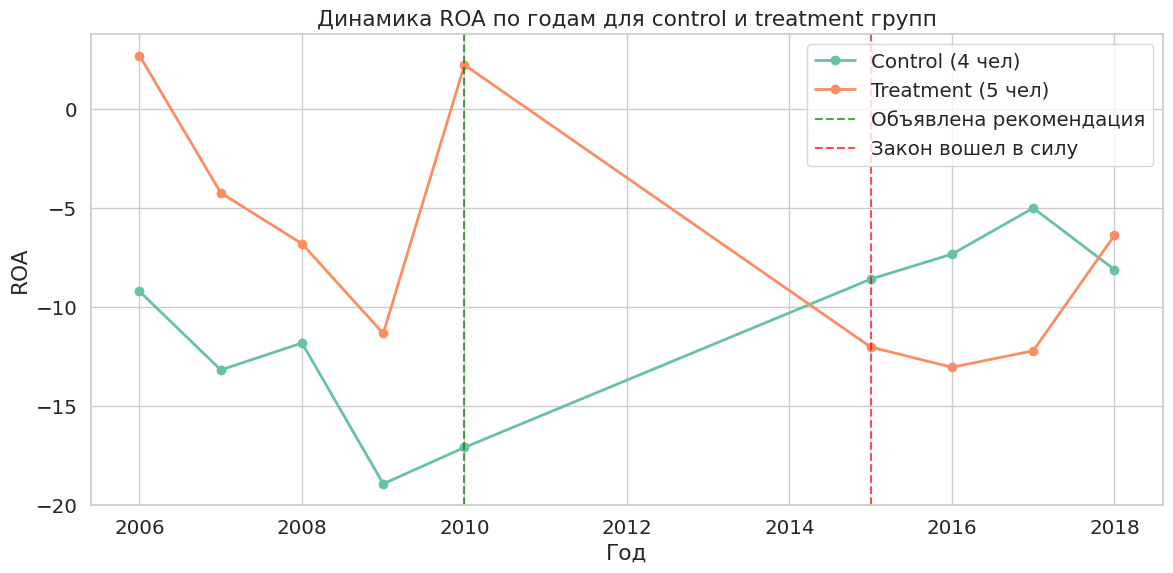

In [74]:
roa_trends = data_did.groupby(['year', 'Treat'])['roa'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
for t in [0, 1]:
    subset = roa_trends[roa_trends['Treat'] == t]
    label = 'Treatment (5 чел)' if t == 1 else 'Control (4 чел)'
    ax.plot(subset['year'], subset['roa'], marker='o', linewidth=2, label=label)
ax.axvline(x=2010, color='green', linestyle='--', alpha=0.7, label='Объявлена рекомендация')
ax.axvline(x=2015, color='red', linestyle='--', alpha=0.7, label='Закон вошел в силу')
ax.set_xlabel('Год')
ax.set_ylabel('ROA')
ax.set_title('Динамика ROA по годам для control и treatment групп')
ax.legend()
plt.tight_layout()
plt.show()

Видим, что до 2010 тренды действительно параллельны на всем участке

In [77]:
data_pre = data_did[data_did['year'] <= 2010].dropna(subset=['roa']).copy()

In [81]:
data_pre['Treat_year'] = data_pre['Treat'].astype(str) + '_' + data_pre['year'].astype(str)
model_placebo_interact = sm.OLS.from_formula('roa ~ Treat * C(year)', data=data_pre).fit()
model_placebo_interact_robust = model_placebo_interact.get_robustcov_results(cov_type='cluster', groups=data_pre['id'])
print("Плацебо-тест: ROA ~ Treat * year (pre-2015)")
print(model_placebo_interact_robust.summary().tables[1])

Плацебо-тест: ROA ~ Treat * year (pre-2015)
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -9.2012      5.710     -1.611      0.109     -20.461       2.059
C(year)[T.2007.0]          -3.9741      5.662     -0.702      0.484     -15.141       7.192
C(year)[T.2008.0]          -2.6123      5.789     -0.451      0.652     -14.028       8.803
C(year)[T.2009.0]          -9.7340      5.681     -1.713      0.088     -20.937       1.469
C(year)[T.2010.0]          -7.8929      7.074     -1.116      0.266     -21.844       6.058
Treat                      11.9226      6.168      1.933      0.055      -0.241      24.086
Treat:C(year)[T.2007.0]    -2.9676      7.594     -0.391      0.696     -17.944      12.009
Treat:C(year)[T.2008.0]    -6.9028      6.411     -1.077      0.283     -19.546       5.740
Treat:C(year)[T.2009.0]    -4.3187  

Каждый коэффициент показывает, насколько разница в ROA между группами в соответствующем году отличалась от разницы в 2006 году. Все взаимодействия статистически незначимы (p > 0.05). Это означает, что мы не можем отвергнуть гипотезу о том, что разница между группами была постоянной во все годы до 2015 года.

In [62]:
from scipy.stats import ttest_ind

## Баланс ковариат между группами

In [63]:
covariates = ['ind', 'dirnetwork', 'age', 'nquals']

data_2010 = data_did[data_did['year'] == 2010].copy()

balance_list = []
for var in covariates:
    mean0 = data_2010[data_2010['Treat'] == 0][var].mean()
    mean1 = data_2010[data_2010['Treat'] == 1][var].mean()
    diff = mean1 - mean0
    group0 = data_2010[data_2010['Treat'] == 0][var].dropna()
    group1 = data_2010[data_2010['Treat'] == 1][var].dropna()
    t_stat, p_val = ttest_ind(group0, group1, equal_var=False)
    balance_list.append({
        'Variable': var,
        'Mean (control)': mean0,
        'Mean (treatment)': mean1,
        'Difference': diff,
        'p-value': p_val
    })
balance_df = pd.DataFrame(balance_list)
print("Баланс ковариат за 2010 год")
print(balance_df.round(4))

Баланс ковариат за 2010 год
     Variable  Mean (control)  Mean (treatment)  Difference  p-value
0         ind          0.3346            0.4377      0.1031   0.0403
1  dirnetwork        756.7692          785.9365     29.1672   0.7777
2         age         57.0949           56.6255     -0.4694   0.6057
3      nquals          1.5615            1.5203     -0.0412   0.7004


Три из четырёх переменных (dirnetwork, age, nquals) сбалансированы — различия между группами статистически незначимы, что подтверждает сопоставимость групп до политики.

In [82]:
placebo_cov_results = {}
covariates = ['ind', 'dirnetwork', 'age', 'nquals']
for var in covariates:
    data_cov = data_pre.dropna(subset=[var]).copy()
    formula = f'{var} ~ Treat + C(year)'
    model_cov = sm.OLS.from_formula(formula, data=data_cov).fit()
    model_cov_robust = model_cov.get_robustcov_results(cov_type='cluster', groups=data_cov['id'])

    coef = model_cov_robust.params[1]
    pval = model_cov_robust.pvalues[1]

    placebo_cov_results[var] = {'coef': coef, 'p-value': pval}
print("Плацебо-тест на значимость разности значений ковариат до тритмента")
placebo_df = pd.DataFrame(placebo_cov_results).T
print(placebo_df)

Плацебо-тест на значимость разности значений ковариат до тритмента
                 coef   p-value
ind          0.003664  0.766885
dirnetwork  17.476920  0.504536
age         -0.238854  0.379297
nquals       0.027820  0.318346


# DID регрессия без контролей**

Оценена регрессия вида $ROA = α + \beta_1 * Treat + \beta_2 * Post + \beta_3 * Treat × Post + ϵ$, где Treat - индикатор группы лечения (фирмы с 5 членами совета), Post - индикатор пост-периода (2015 и позже). Стандартные ошибки кластеризованы на уровне фирмы для учёта корреляции наблюдений внутри одной фирмы.

In [24]:
data_did_clean = data_did.dropna(subset=['roa'])

model_did = sm.OLS.from_formula('roa ~ Treat + Post + Treat_Post', data=data_did_clean).fit()
model_did_robust = model_did.get_robustcov_results(cov_type='cluster', groups=data_did_clean['id'])       #кластеризуем ошибки на уровне фирм
print(model_did_robust.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -14.3950      4.415     -3.260      0.001     -23.101      -5.689
Treat         10.7782      4.837      2.228      0.027       1.239      20.317
Post           7.1598      3.975      1.801      0.073      -0.678      14.998
Treat_Post   -14.4737      4.983     -2.904      0.004     -24.300      -4.648


DiD-оценка говорит о статистически значимом отрицательном эффекте политики на ROA (ATT). В пост-периоде фирмы с 5 членами совета потеряли в среднем 14.5 п.п. ROA относительно фирм с 4 членами.

## Falsification test. DID на pre-периоде**

Для проверки робастности предположения о параллельных трендах назначилм фиктивную дату treatment'а - 2009 год, оценим DiD на данных только для 2010 года.

In [83]:
data_fake = data_did[data_did['year'] <= 2010].dropna(subset=['roa']).copy()
data_fake['Fake_Post'] = (data_fake['year'] >= 2009).astype(int)
data_fake['Fake_Treat_Post'] = data_fake['Treat'] * data_fake['Fake_Post']

model_fake = sm.OLS.from_formula('roa ~ Treat + Fake_Post + Fake_Treat_Post', data=data_fake).fit()
robust_fake = model_fake.get_robustcov_results(cov_type='cluster', groups=data_fake['id'])
print(robust_fake.summary().tables[1])

                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         -11.5542      4.458     -2.592      0.010     -20.345      -2.764
Treat               8.5187      5.213      1.634      0.104      -1.761      18.798
Fake_Post          -6.4218      4.827     -1.330      0.185     -15.941       3.097
Fake_Treat_Post     5.0945      5.567      0.915      0.361      -5.884      16.073


Коэффициент при Fake_Treat_Post составляет 5.09 и статистически незначим (p = 0.361). Это означает, что мы не наблюдаем значимого эффекта политики в период, когда её ещё не было.

Фальсификационный тест пройден: отсутствие значимого эффекта на фиктивную дату подтверждает, что различия между группами не возникли до реального вмешательства, что поддерживает предположение о параллельности трендов.

# IV

## First stage IV. Влияние политики на female**

Регрессия вероятности наличия женщин в совете директоров (female) на индикатор группы лечения (Treat), индикатор пост-периода (Post) и их взаимодействие (Treat_Post). Стандартные ошибки кластеризованы на уровне фирмы.

In [85]:
data_iv = data_did.dropna(subset=['roa', 'female']).copy()

first_stage = sm.OLS.from_formula('female ~ Treat + Post + Treat_Post', data=data_iv).fit()
first_stage_robust = first_stage.get_robustcov_results(cov_type='cluster', groups=data_iv['id'])
print(first_stage_robust.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -5.249e-16        nan        nan        nan         nan         nan
Treat       2.479e-16        nan        nan        nan         nan         nan
Post           0.2062      0.044      4.726      0.000       0.120       0.292
Treat_Post     0.2162      0.059      3.681      0.000       0.100       0.332


Стандартные ошибки для Intercept и Treat отображаются как nan из-за технической особенности кластеризации: Treat не меняется внутри фирмы, и её вариация полностью поглощается кластеризацией на уровне фирмы. Это не влияет на основной коэффициент Treat_Post

После 2015 года у фирм с 5 членами совета вероятность наличия женщин увеличилась на 21.6 п.п. по сравнению с фирмами с 4 членами

## F-статистика первого шага

In [86]:
f_test = first_stage.f_test(['Treat_Post = 0'])
f_test

<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=40.438850536021185, p=2.615196528646647e-10, df_denom=1.66e+03, df_num=1>

F-статистика для Treat_Post: F = 40.4 (p < 0.001), что значительно превышает порог 16, а значит не можем считать инструмент слабым

## Reduced form

In [87]:
reduced_form = sm.OLS.from_formula('roa ~ Treat + Post + Treat_Post', data=data_iv).fit()
reduced_robust = reduced_form.get_robustcov_results(cov_type='cluster', groups=data_iv['id'])
print(reduced_robust.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -14.3950      4.415     -3.260      0.001     -23.101      -5.689
Treat         10.7782      4.837      2.228      0.027       1.239      20.317
Post           7.1598      3.975      1.801      0.073      -0.678      14.998
Treat_Post   -14.4737      4.983     -2.904      0.004     -24.300      -4.648


Получаем аналогичный DiD результат, так как модель специфицирована также

## Wald estimator

In [88]:
reduced_form_coef = reduced_form.params['Treat_Post']
first_stage_coef = first_stage.params['Treat_Post']
wald_iv = reduced_form_coef / first_stage_coef
print(f'Wald estimator: {wald_iv}')

Wald estimator: -66.94457265506429


Эффект наличия женщин в совете директоров на ROA для комплаеров (фирм, которые добавили женщин в совет именно под влиянием политики 2015 года и не сделали бы этого без неё) - LATE составляет -66.9 п.п.

Масштаб эффекта значительно превышает ATT, поскольку только 21.6% фирм в группе treatment реально изменили состав совета. Весь наблюдаемый эффект политики концентрируется на этой подгруппе

## IV через библиотеку linearmodels для сравнения

In [89]:
!pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 8.3 MB/s eta 0:00:00


In [90]:
from linearmodels.iv import IV2SLS

model_iv = IV2SLS.from_formula('roa ~ 1 + Treat + Post + [female ~ Treat_Post]', data=data_iv).fit(cov_type='clustered', clusters=data_iv['id'])
print(model_iv.summary.tables[1])

                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept     -14.395     4.4003    -3.2714     0.0011     -23.019     -5.7706
Treat          10.778     4.8211     2.2356     0.0254      1.3289      20.227
Post           20.965     10.548     1.9876     0.0469      0.2918      41.639
female        -66.945     30.451    -2.1984     0.0279     -126.63     -7.2620


# Fixed effects

In [91]:
import linearmodels.iv as iv
from linearmodels.panel import PanelOLS

data_panel = data_did.set_index(['id', 'year']).copy()

## DiD с FE (Firm FE, Year FE)

$ROA_{it} = \alpha Treat_{Post} + λ_i + γ_t + ϵ_{it}$

EntityEffects - фиксированные эффекты на уровне фирмы


TimeEffects - фиксированные эффекты на уровне года

In [94]:
formula_did_fe = 'roa ~  Treat_Post + EntityEffects + TimeEffects'

model_did_fe = PanelOLS.from_formula(formula_did_fe, data=data_panel)

results_did_fe = model_did_fe.fit(cov_type='clustered', cluster_entity=True)
print("DID c Firm and Year FE")
print(results_did_fe.summary)

DID c Firm and Year FE
                          PanelOLS Estimation Summary                           
Dep. Variable:                    roa   R-squared:                        0.0113
Estimator:                   PanelOLS   R-squared (Between):              0.0498
No. Observations:                1666   R-squared (Within):              -0.0045
Date:                Sat, Jun 27 2026   R-squared (Overall):              0.0175
Time:                        19:54:56   Log-likelihood                   -8141.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      16.573
Entities:                         202   P-value                           0.0000
Avg Obs:                       8.2475   Distribution:                  F(1,1455)
Min Obs:                       1.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             7.0134
     

Видим, что добавление фиксированных эффектов привело к незначительному усилению отрицательного эффекта с –14.47 до –14.99. Это означает, что контроль постоянных ненаблюдаемых характеристик фирм немного увеличил оценку эффекта политики по модулю

Это могло произойти из-за корреляции постоянных факторов с treatment'ом: если фирмы с 5 членами совета имели в среднем более высокое качество управления (что могло давать им преимущество в ROA до политики), то без FE эта разница частично забирала бы эффект политики. FE убирают это преимущество, делая оценку более отрицательной.

## IV (2SLS) с FE

In [125]:
data_iv_fe = data_did.dropna(subset=['roa', 'female', 'Treat_Post', 'id', 'year']).copy()

formula_iv_fe = 'roa ~ 1 + C(id) + C(year) + [female ~ Treat_Post]'
model_iv_fe = iv.IV2SLS.from_formula(formula_iv_fe, data=data_iv_fe)
results_iv_fe = model_iv_fe.fit(cov_type='clustered', clusters=data_iv_fe['id'])

print("Результаты First stage FE")
fs = results_iv_fe.first_stage
print(f"Коэффициент при Treat_Post: {fs.individual['female'].params['Treat_Post']:.4f}")
print(f"pvalue: {fs.individual['female'].pvalues['Treat_Post']:.4f}")
print(f"F-статистика: {fs.diagnostics['f.stat'][0]:.4f}")
print(f"Коэффициент при female: {results_iv_fe.params['female']:.4f}")
print(f"pvalue: {results_iv_fe.pvalues['female']:.4f}")

Результаты First stage FE
Коэффициент при Treat_Post: 0.2320
pvalue: 0.0001
F-статистика: 15.2041
Коэффициент при female: -64.6305
pvalue: 0.0260


После контроля фиксированных эффектов фирмы и года, политика увеличивает вероятность наличия женщин в совете на 23.2 п.п. для фирм группы лечения по сравнению с контрольной группой. Эффект статистически значим (p < 0.001). F‑статистика = 15.2, что превышает порог 10, что сигнализирует о том, что инструмент является слабым. F-статистика снизилась по сравнению с моделью без FE - 40.4, что ожидаемо, так как FE забирают часть вариации

Добавление фиксированных эффектов привело к небольшому ослаблению отрицательного эффекта с –66.94 до –64.63. Это означает, что контроль постоянных ненаблюдаемых факторов немного уменьшил оценку LATE по модулю

# Robustness check

Чтобы проверить, не обусловлены ли наши результаты выбором конкретного временного окна, повторим оценку DiD и IV на усечённой выборке: Pre-период ограничен 2008-2010 годами вместо 2006-2010, Post-период - 2015-2017 вместо 2015-2018. Это позволит исключить возможное влияние крайних годов на оценки.

In [136]:
data_window = data_did[
    ((data_did['year'] >= 2008) & (data_did['year'] <= 2010)) |
    ((data_did['year'] >= 2015) & (data_did['year'] <= 2017))
].dropna(subset=['roa']).copy()

formula_window = 'roa ~ Treat + Post + Treat_Post'
model_window = sm.OLS.from_formula(formula_window, data=data_window).fit()
results_window = model_window.get_robustcov_results(cov_type='cluster', groups=data_window['id'])

print("DID с меньшим временным окном (от 2008 до 2010 для C и от 2015 до 2017 для T)")
print(results_window.summary().tables[1])
reduced_form_coef = results_window.params[-1]

DID с меньшим временным окном (от 2008 до 2010 для C и от 2015 до 2017 для T)
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -16.0040      4.601     -3.479      0.001     -25.076      -6.932
Treat         10.8663      4.929      2.205      0.029       1.147      20.586
Post           9.0559      4.177      2.168      0.031       0.819      17.293
Treat_Post   -16.3421      5.469     -2.988      0.003     -27.127      -5.557


ATT остаётся отрицательным и значимым, но становится меньше –16.34.

In [139]:
data_window = data_iv[
    ((data_iv['year'] >= 2008) & (data_iv['year'] <= 2010)) |
    ((data_iv['year'] >= 2015) & (data_iv['year'] <= 2017))
].dropna(subset=['roa', 'female']).copy()

first_stage = sm.OLS.from_formula('female ~ Treat + Post + Treat_Post', data=data_window).fit()
first_stage_robust = first_stage.get_robustcov_results(cov_type='cluster', groups=data_window['id'])
print("DID с меньшим временным окном (от 2008 до 2010 для C и от 2015 до 2017 для T)")
print(first_stage_robust.summary().tables[1])

first_stage_coef = first_stage_robust.params[-1]

DID с меньшим временным окном (от 2008 до 2010 для C и от 2015 до 2017 для T)
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4.302e-17   2.26e-09    1.9e-08      1.000   -4.46e-09    4.46e-09
Treat       2.523e-16   2.25e-09   1.12e-07      1.000   -4.43e-09    4.43e-09
Post           0.1762      0.043      4.110      0.000       0.092       0.261
Treat_Post     0.2308      0.059      3.936      0.000       0.115       0.346


Первая ступень также остаётся сильной и значимой

In [140]:
f_test = first_stage.f_test(['Treat_Post = 0'])
f_test

<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=30.818627577850258, p=3.511922477806158e-08, df_denom=1.16e+03, df_num=1>

F ≈ 30.8, что ниже 40, при уменьшении выборки сила инструмента падает

In [138]:
reduced_form_coef = reduced_form.params['Treat_Post']
first_stage_coef = first_stage.params['Treat_Post']
wald_iv = reduced_form_coef / first_stage_coef
print(f'Wald estimator: {wald_iv}')

Wald estimator: -62.71587033974993


Wald IV (LATE) составляет -62.72, что близко к основной оценке -66.94. Это указывает на то, что эффект наличия женщин для комплаеров устойчив к изменению временного окна